In [1]:
# --- Connect to Google-Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -qq pymc

In [3]:
from typing import List, Union

#import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import xarray as xr
from scipy.optimize import minimize_scalar

# --- File Loading
import pickle
import cloudpickle


seed = sum(map(ord, "sfm"))
rng = np.random.default_rng(seed)

pm.__version__

'5.28.5'

In [4]:
# -------------------------------------- USER INTERACTION -------------------------------------- #

# --- Set the directory to the datafile ('SFM_data_byPlayer.csv'):
directory = './'

# --- Cross-Sectional Standardization, or whole-sample Standardization?
do__scaleCS = True

# -------------------------------------- USER INTERACTION -------------------------------------- #

In [5]:
if do__scaleCS:
  scale__type = '_scaleCS' # --- cross-sectional
else:
  scale__type = '_scaleWS' # --- whole-sample

<br>

## 00. &emsp; Auxiliaries

In [6]:
def compute_log_likelihood(predictions, actuals):
    """
    predictions: array of shape (n_samples, n_categories)
                 e.g., [[0.4, 0.35, 0.2, 0.05], ...] for one match
    actuals: array of actual outcomes [0, 1, 2, 3, ...]
    """
    log_lik = 0
    for i, actual in enumerate(actuals):
        # Get probability assigned to actual outcome
        prob_actual = predictions[i][actual]
        log_lik += np.log(prob_actual + 1e-10)  # Add small epsilon to avoid log(0)

    return log_lik


def log_loss_categorical(probs, actuals, eps=1e-10):
    return -np.mean(np.log(probs[np.arange(len(actuals)), actuals] + eps))


def multi_class_brier_score(predictions, actuals, n_classes=4):
    """
    predictions: (n_samples, n_classes) probability matrix
    actuals: (n_samples,) actual outcomes
    """
    # Convert actuals to one-hot encoding
    one_hot = np.zeros((len(actuals), n_classes))
    one_hot[np.arange(len(actuals)), actuals] = 1

    # Compute Brier score
    brier = np.mean(np.sum((predictions - one_hot)**2, axis=1))
    return brier


def ranked_probability_score(predictions, actuals, n_classes=4):
    """
    Ranked Probability Score for ordinal outcomes
    """
    rps = 0
    for i, actual in enumerate(actuals):
        # Cumulative probabilities
        pred_cumsum = np.cumsum(predictions[i])

        # Actual cumulative (one-hot converted to cumulative)
        actual_cumsum = np.zeros(n_classes)
        actual_cumsum[actual:] = 1

        # RPS for this prediction
        rps += np.sum((pred_cumsum - actual_cumsum)**2)

    return rps / len(actuals)



def expected_calibration_error(predictions, actuals, n_bins=10):
    """
    ECE for probabilistic predictions
    """
    # Get predicted probabilities for actual class
    pred_probs = predictions[np.arange(len(actuals)), actuals]

    # Create bins
    bin_edges = np.linspace(0, 1, n_bins + 1)

    ece = 0
    for i in range(n_bins):
        # Find predictions in this bin
        in_bin = (pred_probs >= bin_edges[i]) & (pred_probs < bin_edges[i+1])

        if np.sum(in_bin) > 0:
            # Average predicted probability in bin
            avg_pred = np.mean(pred_probs[in_bin])

            # Actual accuracy in bin (for max predicted class)
            max_pred = np.argmax(predictions[in_bin], axis=1)
            avg_actual = np.mean(max_pred == actuals[in_bin])

            # Weighted by bin size
            ece += np.abs(avg_pred - avg_actual) * np.sum(in_bin)

    return ece / len(actuals)


def ordinal_accuracy(predictions, actuals):
    """
    Percentage of times the highest probability category was correct
    """
    pred_classes = np.argmax(predictions, axis=1)
    return np.mean(pred_classes == actuals)


def ordinal_mae(predictions, actuals):
    """
    MAE treating categories as ordinal
    """
    pred_classes = np.argmax(predictions, axis=1)
    return np.mean(np.abs(pred_classes - actuals))


def update_elo(r_home, r_away, result, K=20, home_adv=50):
    exp_home = 1 / (1 + 10 ** ((r_away - r_home - home_adv) / 400))
    if result == 2:    # home win
        s_home = 1.0
    elif result == 1:  # draw
        s_home = 0.5
    elif result == 0:  # away win
        s_home = 0.0
    else:
        raise ValueError("Invalid result value. Must be 0, 1, or 2.")

    r_home_new = r_home + K * (s_home - exp_home)
    r_away_new = r_away + K * ((1 - s_home) - (1 - exp_home))
    return r_home_new, r_away_new



def softmax(x):
    return np.exp(x)/sum(np.exp(x))

In [ ]:
def _logloss(probs, actuals, eps=1e-12):
    p = np.clip(probs[np.arange(len(actuals)), actuals], eps, 1.0)
    return -np.mean(np.log(p))


def apply_temperature(probs, T, eps=1e-12):
    """p^(1/T) renormalised  ==  softmax(log p / T).  T<1 sharpens, T>1 softens."""
    z = np.log(np.clip(probs, eps, 1.0)) / T
    z -= z.max(axis=1, keepdims=True)              # numerical stability
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def fit_temperature(probs, actuals, bounds=(0.3, 3.0)):
    """Single scalar T minimising log-loss."""
    res = minimize_scalar(lambda T: _logloss(apply_temperature(probs, T), actuals),
                          bounds=bounds, method='bounded')
    return float(res.x)


def stack_preds(dict_preds):
    """Pull (probs, actuals, fold-label) out of dict_preds. Columns ['0','1','2'] = [away,draw,home]."""
    P, Y, folds = [], [], []
    for k, v in dict_preds.items():
        if not len(v): continue
        P.append(v['Yhat'][['0', '1', '2']].to_numpy(dtype=float))
        Y.append(v['Y__SFM']['match_outcome'].to_numpy(dtype=int))
        folds += [k] * len(Y[-1])
    return np.vstack(P), np.concatenate(Y), np.array(folds)


def temperature_diagnostic(dict_preds):
    """Pooled fit + honest leave-one-fold-out gain. Returns the production T (fit on ALL folds)."""
    P, Y, folds = stack_preds(dict_preds)
    ufolds = list(dict.fromkeys(folds))

    T_all = fit_temperature(P, Y)
    ll0, ll1 = _logloss(P, Y), _logloss(apply_temperature(P, T_all), Y)
    print("=" * 64)
    print(f"POOLED:  T* = {T_all:.3f}   log-loss {ll0:.4f} -> {ll1:.4f}   (in-sample)")
    direction = ("UNDER-confident (sharpen)" if T_all < 0.97
                 else "OVER-confident (soften)" if T_all > 1.03
                 else "already well-calibrated")
    print(f"         => model was {direction}")
    print("-" * 64)
    print("LEAVE-ONE-FOLD-OUT (honest held-out gain):")
    tot0 = tot1 = 0.0
    for f in ufolds:
        tr, te = folds != f, folds == f
        Tf = fit_temperature(P[tr], Y[tr])               # fit on OTHER folds
        l0 = _logloss(P[te], Y[te]); l1 = _logloss(apply_temperature(P[te], Tf), Y[te])
        tot0 += l0 * te.sum(); tot1 += l1 * te.sum()
        print(f"  {f:>10s}:  T(others)={Tf:.3f}   {l0:.4f} -> {l1:.4f}   (Δ {l1 - l0:+.4f})")
    n = len(Y)
    print("-" * 64)
    print(f"  HELD-OUT TOTAL:  {tot0/n:.4f} -> {tot1/n:.4f}   (Δ {(tot1-tot0)/n:+.4f})")
    print("=" * 64)
    return T_all


def reliability_plot(probs, actuals, T=None, n_bins=10, min_bin=8):
    """Per-class reliability curves; overlays T-scaled if T given. On-diagonal = calibrated."""
    classes = ['away win', 'draw', 'home win']
    variants = [(probs, 'raw', 'C0')] + ([(apply_temperature(probs, T), f'T={T:.2f}', 'C1')] if T else [])
    edges = np.linspace(0, 1, n_bins + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for k, ax in enumerate(axes):
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
        for p, lab, col in variants:
            pk, ak = p[:, k], (actuals == k).astype(float)
            cx, cy = [], []
            for i in range(n_bins):
                msk = (pk >= edges[i]) & (pk < edges[i + 1])
                if msk.sum() >= min_bin:
                    cx.append(pk[msk].mean()); cy.append(ak[msk].mean())
            ax.plot(cx, cy, 'o-', color=col, label=lab)
        ax.set_title(classes[k]); ax.set_xlabel('predicted P'); ax.set_ylabel('observed freq')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend()
    plt.tight_layout(); plt.show()

<br>

## 1. &emsp; Out-of-Sample -- Comparison with Betting Odds

In [76]:
# ===================================== Load Models ===================================== #
dict_models = {}

for devVersion in ['A', 'B', 'C','D', 'E', 'F', 'G', 'H', 'I','J','K']:

  # --- Set the path to the file to be loaded:
  pickle_filepath = f'{directory}/10_data/102_Development/Evaluation__SFMMOwm_Dev{devVersion}_{scale__type}__EW.pkl'


  # --- Load the file
  with open(pickle_filepath, "rb") as f:
    dict_models[devVersion] = cloudpickle.load(f)



POOLED:  T* = 0.850   log-loss 0.8823 -> 0.8244   (in-sample)
         => model was UNDER-confident (sharpen)
----------------------------------------------------------------
LEAVE-ONE-FOLD-OUT (honest held-out gain):
     WMQ2018:  T(others)=0.863   0.9047 -> 0.8465   (Δ -0.0581)
      WM2018:  T(others)=0.846   0.9948 -> 0.9651   (Δ -0.0297)
     WMQ2022:  T(others)=0.883   0.8497 -> 0.7921   (Δ -0.0576)
      WM2022:  T(others)=0.844   1.0259 -> 1.0093   (Δ -0.0166)
     WMQ2026:  T(others)=0.822   0.8710 -> 0.8099   (Δ -0.0610)
----------------------------------------------------------------
  HELD-OUT TOTAL:  0.8823 -> 0.8252   (Δ -0.0571)


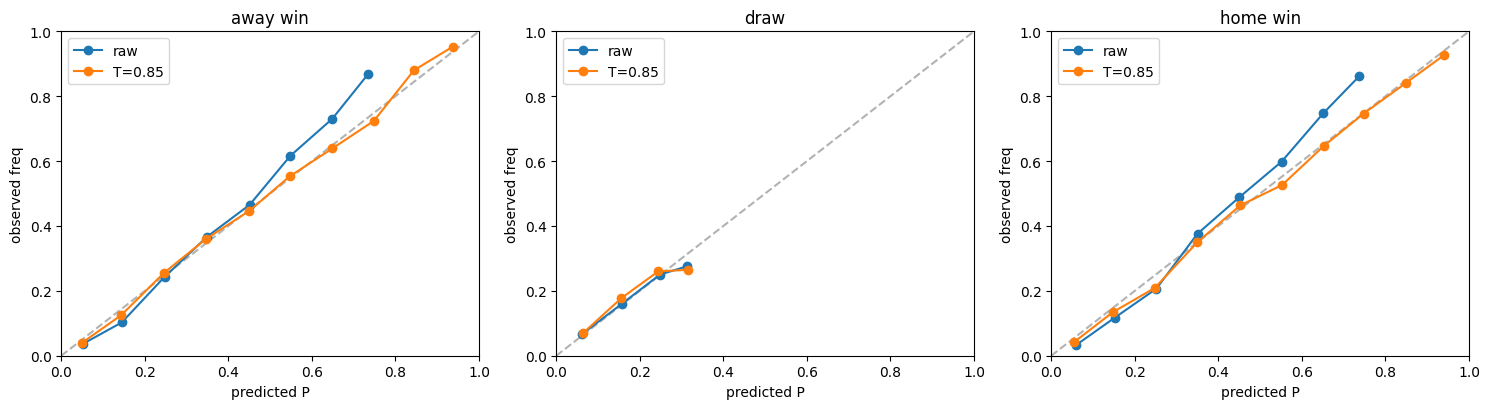

In [77]:
# ===================================== Temperature Scaling ===================================== #

"""
  Diagnoses (and optionally fixes) under/over-confidence in the forecasts.
"""


# ------------------- USER INTERACTION ------------------- #

# --- Pick a Version: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J','K']
devVersion = 'K'

# ------------------- USER INTERACTION ------------------- #


# --- Get the 'global' Scaler:
T_global = temperature_diagnostic(dict_models[devVersion]['dict_preds'])

# --- Diagnostic Plots:
P, Y, _ = stack_preds(dict_models[devVersion]['dict_preds'])
reliability_plot(P, Y, T=T_global)

In [78]:
# ================================== Out-of-Sample Evaluation ================================== #


# ----------------------------- USER INTERACTION ----------------------------- #

# --- Apply Calibration?
T_star = None

# ----------------------------- USER INTERACTION ----------------------------- #


dict_eval = {}

for devVersion in dict_models.keys():
  dict_preds = dict_models[devVersion]['dict_preds']

  df_eval = pd.DataFrame(np.nan, index=list(dict_preds.keys()) + ['all'], columns=['logLik','ACC','RPS','Brier'])

  for s in df_eval.index:

    if s == 'all':
      s__Yhat = np.concatenate([dict_preds[s]['Yhat'].values for s in dict_preds.keys()])
      s__Y = np.concatenate([dict_preds[s]['Y__SFM']['match_outcome'].values for s in dict_preds.keys()])
    else:
      s__Yhat = dict_preds[s]['Yhat'].values
      s__Y = dict_preds[s]['Y__SFM']['match_outcome'].values


    if T_star is not None:
      s__Yhat = apply_temperature(s__Yhat, T_star)


    df_eval.loc[s,'logLik'] = log_loss_categorical(s__Yhat, s__Y.astype(int))
    df_eval.loc[s,'ACC'] = ordinal_accuracy(s__Yhat, s__Y)
    df_eval.loc[s,'RPS'] = ranked_probability_score(s__Yhat, s__Y, n_classes=3)
    df_eval.loc[s,'Brier'] = multi_class_brier_score(s__Yhat, s__Y.astype(int), n_classes=3)

    dict_eval[devVersion] = df_eval.copy()

In [79]:
# ------------------- USER INTERACTION ------------------- #

# --- Pick a Version: ['A','B','C' ,'D', 'E', 'F', 'G', 'H', 'I','J','K']
devVersion = 'K'

# ------------------- USER INTERACTION ------------------- #

print(f'\nVersion: {devVersion}')
dict_eval[devVersion].round(4)


Version: K


,logLik,ACC,RPS,Brier
WMQ2018,0.9047,0.6425,0.3520,0.5043
WM2018,0.9948,0.6250,0.4410,0.5684
WMQ2022,0.8497,0.6555,0.3134,0.4730
WM2022,1.0259,0.5156,0.4389,0.5803
WMQ2026,0.8710,0.6298,0.3259,0.4852
all,0.8823,0.6391,0.3363,0.4921


In [80]:
# ================================== Load the Odds ================================== #

data_odds__raw = pd.read_csv(f'{directory}/10_data/102_Development/odds_byMatch__WM.csv')


In [81]:
# ================================== Infer Probs from Betting Odds ================================== #


def implied_probs_from_decimal_odds(odds_w, odds_d, odds_l):
    """Strip the bookmaker margin from decimal odds and return normalized probs."""
    raw = np.array([1/odds_w, 1/odds_d, 1/odds_l])
    return raw / raw.sum(axis=0)           # simple proportional de-vig


# ------------------- USER INTERACTION ------------------- #

# --- Betting Outlets: ['B365','PS','Max','Avg']
pick_bookmaker = 'Avg'

# ------------------- USER INTERACTION ------------------- #

data_odds = data_odds__raw.copy()

# --- Drop NAs:
data_odds = data_odds.dropna(subset=[f'{pick_bookmaker}{i}' for i in ['H','D','A']])

assert data_odds.shape[0] > 0, f'[ERROR]: No betting odds available for bookmaker: {pick_bookmaker}'


outlet_probs = implied_probs_from_decimal_odds(data_odds[f'{pick_bookmaker}H'].astype(float).values,
                                               data_odds[f'{pick_bookmaker}D'].astype(float).values,
                                               data_odds[f'{pick_bookmaker}A'].astype(float).values)

data_odds[f'{pick_bookmaker}_probs__homeW'] = outlet_probs[0]
data_odds[f'{pick_bookmaker}_probs__homeD'] = outlet_probs[1]
data_odds[f'{pick_bookmaker}_probs__homeL'] = outlet_probs[2]


In [82]:
# ================================== Bookmaker Evaluation ================================== #


# --- Which seasons are overlapping:
idx = data_odds.loc[data_odds['season'].isin(dict_preds.keys()),'season'].unique().tolist()


assert len(idx) > 0, f'[ERROR]: No betting odds provided for any Validation Period by Bookmaker: {pick_bookmaker}'


df_eval__odds = pd.DataFrame(np.nan, index= idx + ['all'], columns=['logLik','ACC','RPS','Brier'])

for s in df_eval__odds.index:

  if s == 'all':
    df__Y = pd.concat([dict_preds[s]['Y__SFM'] for s in dict_preds.keys()]).set_index('id_match')
  else:
    df__Y = dict_preds[s]['Y__SFM'].set_index('id_match')

  # --- Collect the Odds:
  df__Yhat = data_odds[['id_match'] + [f'{pick_bookmaker}_probs__home{i}' for i in ['W','D','L']]].copy().set_index('id_match')

  # --- Merge on `id_match'
  df__Yhat = pd.merge(df__Yhat,df__Y, left_index=True, right_index=True, how='left').dropna()

  # --- For Compatibility:
  s__Yhat = df__Yhat[[f'{pick_bookmaker}_probs__home{i}' for i in ['L','D','W']]].values
  s__Y = df__Yhat['match_outcome'].values


  df_eval__odds.loc[s,'logLik'] = log_loss_categorical(s__Yhat, s__Y.astype(int))
  df_eval__odds.loc[s,'ACC'] = ordinal_accuracy(s__Yhat, s__Y)
  df_eval__odds.loc[s,'RPS'] = ranked_probability_score(s__Yhat, s__Y, n_classes=3)
  df_eval__odds.loc[s,'Brier'] = multi_class_brier_score(s__Yhat, s__Y.astype(int), n_classes=3)

  print(f'\nSeason: {s} --- Number of Matches: {len(s__Y)}')



Season: WMQ2026 --- Number of Matches: 762

Season: WM2022 --- Number of Matches: 64

Season: WM2018 --- Number of Matches: 64

Season: WMQ2018 --- Number of Matches: 819

Season: all --- Number of Matches: 1709


In [83]:
print(f'\nMetric: log-Likelihood')
df_eval = pd.DataFrame(df_eval__odds['logLik'])
df_eval.columns = [f'Bookmaker -- {pick_bookmaker}']
for key in dict_eval.keys():
  key_eval = pd.DataFrame(dict_eval[key]['logLik'])
  key_eval.columns = [f'{key}']
  df_eval = pd.merge(df_eval,key_eval, left_index=True, right_index=True, how='left')

df_eval.loc[df_eval.index != 'all',:].round(3)



Metric: log-Likelihood


,Bookmaker -- Avg,A,B,C,D,E,F,G,H,I,J,K
WMQ2026,0.742,0.871,0.872,0.871,0.871,0.870,0.871,0.871,0.871,0.883,0.871,0.871
WM2022,1.001,1.026,1.025,1.028,1.028,1.023,1.025,1.027,1.028,1.034,1.026,1.026
WM2018,0.933,0.995,0.996,0.999,1.001,0.991,0.993,0.999,1.000,1.032,0.995,0.995
WMQ2018,0.780,0.905,0.905,0.905,0.905,0.907,0.906,0.907,0.905,0.912,0.905,0.905


In [84]:
print(f'\nMetric: Accuracy')
df_eval = pd.DataFrame(df_eval__odds['ACC'])
df_eval.columns = [f'Bookmaker -- {pick_bookmaker}']
for key in dict_eval.keys():
  key_eval = pd.DataFrame(dict_eval[key]['ACC'])
  key_eval.columns = [f'{key}']
  df_eval = pd.merge(df_eval,key_eval, left_index=True, right_index=True, how='left')

df_eval.loc[df_eval.index != 'all',:].round(3)



Metric: Accuracy


,Bookmaker -- Avg,A,B,C,D,E,F,G,H,I,J,K
WMQ2026,0.657,0.630,0.631,0.630,0.631,0.634,0.634,0.632,0.632,0.627,0.631,0.630
WM2022,0.578,0.516,0.516,0.516,0.516,0.531,0.531,0.531,0.516,0.547,0.516,0.516
WM2018,0.609,0.625,0.625,0.625,0.625,0.625,0.625,0.625,0.625,0.625,0.625,0.625
WMQ2018,0.669,0.644,0.643,0.641,0.640,0.639,0.640,0.641,0.640,0.632,0.643,0.643


In [85]:
print(f'\nMetric: Ranked Probability Score')
df_eval = pd.DataFrame(df_eval__odds['RPS'])
df_eval.columns = [f'Bookmaker -- {pick_bookmaker}']
for key in dict_eval.keys():
  key_eval = pd.DataFrame(dict_eval[key]['RPS'])
  key_eval.columns = [f'{key}']
  df_eval = pd.merge(df_eval,key_eval, left_index=True, right_index=True, how='left')

df_eval.loc[df_eval.index != 'all',:].round(3)




Metric: Ranked Probability Score


,Bookmaker -- Avg,A,B,C,D,E,F,G,H,I,J,K
WMQ2026,0.271,0.326,0.326,0.326,0.326,0.325,0.326,0.326,0.326,0.332,0.326,0.326
WM2022,0.446,0.440,0.439,0.439,0.439,0.438,0.438,0.438,0.439,0.436,0.439,0.439
WM2018,0.409,0.441,0.441,0.443,0.444,0.439,0.440,0.443,0.443,0.459,0.441,0.441
WMQ2018,0.300,0.352,0.352,0.352,0.352,0.353,0.353,0.353,0.352,0.356,0.352,0.352


In [86]:
print(f'\nMetric: Brier Score')
df_eval = pd.DataFrame(df_eval__odds['Brier'])
df_eval.columns = [f'Bookmaker -- {pick_bookmaker}']
for key in dict_eval.keys():
  key_eval = pd.DataFrame(dict_eval[key]['Brier'])
  key_eval.columns = [f'{key}']
  df_eval = pd.merge(df_eval,key_eval, left_index=True, right_index=True, how='left')

df_eval.loc[df_eval.index != 'all',:].round(3)


Metric: Brier Score


,Bookmaker -- Avg,A,B,C,D,E,F,G,H,I,J,K
WMQ2026,0.432,0.485,0.486,0.485,0.486,0.484,0.485,0.485,0.485,0.490,0.485,0.485
WM2022,0.579,0.581,0.580,0.580,0.580,0.579,0.580,0.579,0.580,0.579,0.580,0.580
WM2018,0.547,0.568,0.569,0.570,0.571,0.566,0.567,0.570,0.570,0.584,0.569,0.568
WMQ2018,0.451,0.504,0.504,0.504,0.504,0.505,0.505,0.505,0.504,0.507,0.504,0.504
